In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from IPython.display import clear_output
from src.fss_collapse_core import collapse_for_c, fit_linear_feedback_model, label
from src.stability_tests import read_dynamic_bundle
plt.style.use('properties.mplstyle')

In [2]:
results_folder = "../results/1Color/2D"
configurations_folder = results_folder + "/configurations"
create_folder(results_folder)
create_folder(configurations_folder)

Folder already exists: ../results/1Color/2D
Folder already exists: ../results/1Color/2D/configurations


In [3]:
df_dynamic = pd.read_csv("../SOP_data/all_colors_dynamic.dat", sep=' ')
df_dynamic

,type_perc,dim,L,f_T,c,num_colors,P0,p0,N_samples,rho,nc,nc_err,nc_std,stat_window
0,bond,2,1024,0.001000,0.01,1,0.5,0.8,606,1.00,0.0,0.0,0.0,300
1,bond,2,2048,0.001000,0.01,1,0.5,0.8,306,1.00,0.0,0.0,0.0,300
2,bond,2,4096,0.001000,0.01,1,0.5,0.8,156,1.00,0.0,0.0,0.0,300
3,bond,2,8192,0.001000,0.01,1,0.5,0.8,81,1.00,0.0,0.0,0.0,300
4,bond,2,1024,0.005308,0.01,1,0.5,0.8,404,1.00,0.0,0.0,0.0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7428,bond,3,1024,0.473737,0.20,4,1.0,0.6,5,0.25,4.0,0.0,0.0,300
7429,bond,3,128,0.500000,0.20,4,1.0,0.6,200,0.25,4.0,0.0,0.0,300
7430,bond,3,256,0.500000,0.20,4,1.0,0.6,150,0.25,4.0,0.0,0.0,300
7431,bond,3,512,0.500000,0.20,4,1.0,0.6,25,0.25,4.0,0.0,0.0,300


In [4]:
df_series = pd.read_csv('../SOP_data/all_data_dynamic.dat', sep=' ')
df_series

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,...,N_samples_perc,p_mean,p_err,f_mean,f_err,z_max_mean,z_max_err,z_stat_mean,z_stat_err,stat_window
0,bond,2,8192,0.022538,0.01,1,1.00,0.8,0.5,0,...,1,0.501080,0.000000,0.022540,0.000000,8192.0,0.0,391.000000,0.000000,300
1,bond,2,8192,0.026846,0.01,1,1.00,0.8,0.5,0,...,2,0.501816,0.000865,0.026897,0.000006,8192.0,0.0,328.000000,12.000000,300
2,bond,2,4096,0.031154,0.01,1,1.00,0.8,0.5,0,...,1,0.501357,0.000000,0.031115,0.000000,4096.0,0.0,294.000000,0.000000,300
3,bond,2,8192,0.031154,0.01,1,1.00,0.8,0.5,0,...,3,0.501402,0.000317,0.031213,0.000025,8192.0,0.0,355.666667,4.666667,300
4,bond,2,4096,0.035462,0.01,1,1.00,0.8,0.5,0,...,4,0.501608,0.000648,0.035541,0.000043,4096.0,0.0,301.000000,12.935739,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16108,bond,3,512,0.500000,0.20,4,0.25,0.6,1.0,3,...,25,1.000000,0.000000,0.250196,0.000191,512.0,0.0,320.000000,0.000000,300
16109,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,0,...,5,1.000000,0.000000,0.250027,0.000210,1024.0,0.0,320.000000,0.000000,300
16110,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,1,...,5,1.000000,0.000000,0.250014,0.000276,1024.0,0.0,320.000000,0.000000,300
16111,bond,3,1024,0.500000,0.20,4,0.25,0.6,1.0,2,...,5,1.000000,0.000000,0.250026,0.000280,1024.0,0.0,320.000000,0.000000,300


# 2D

## $p^*$

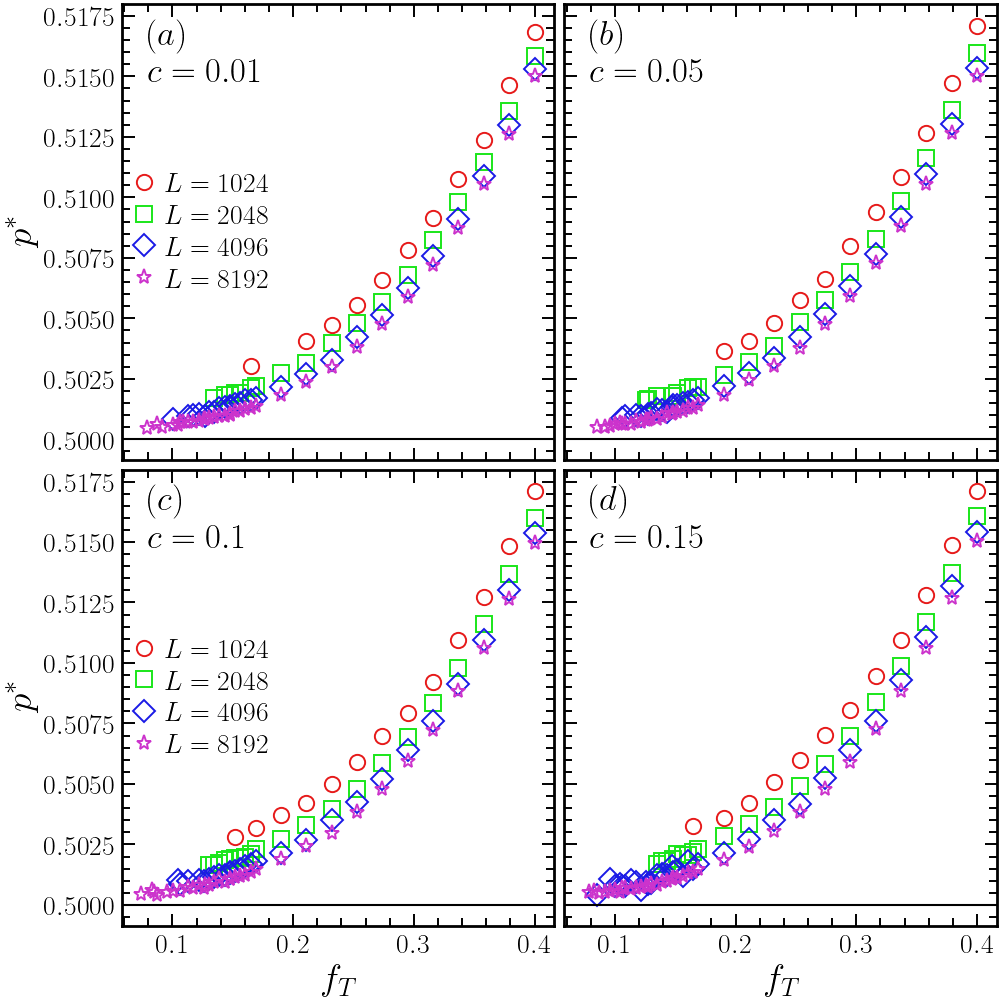

In [7]:
#plt.plot(df_series[(df_series['nc']==4) & (df_dynamic['c']==0.01)]['f_T'],df_dynamic[(df_dynamic['nc']==4) & (df_dynamic['c']==0.01)]['p_mean'], 'o')
L_lst = [1024, 2048, 4096, 8192]
nc = 1
rho = 1/nc
order = 0
p0 = 0.8
P0 = 0.5
dim = 2
c = 0.01
middle_points = []
markers = ['o', 's', 'D', '*']
order = 0
base = 5
c_lst = [0.01, 0.05, 0.1, 0.15]
fs_l_fig = 25
fs_label = 27
pc = 0.5
fig, axes = plt.subplots(2, 2, figsize=(2*base, 2*base), constrained_layout=True, sharey=True, sharex=True)
labels = [r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$"]
for idx_c, ax in enumerate(axes.flatten()):
        c = c_lst[idx_c]
        for idx, L in enumerate(L_lst):
                df_SUB = df_series[(df_series['type_perc']=='bond') & (df_series['p0']==p0) & (df_series['P0']==P0)
                        & (df_series['order']==order) & (df_series['nc']==nc) & (df_series['L']==L)
                        & (df_series['c']==c) & (df_series['dim']==dim)].sort_values(by='f_T').reset_index(drop=True)
                df_filter = df_SUB[df_SUB['N_samples']==df_SUB['N_samples_perc']]
                
                df_plot = df_filter.sort_values("f_T").copy()
                
                df_plot = df_plot[(df_plot["p_mean"] >= 0) & (df_plot["p_mean"] <= 1)]
                df_plot = df_plot[df_plot["N_samples_perc"] >= 5]
                df_plot = df_plot[df_plot["p_mean"] < 0.90]  # se quiser remover regime saturado
                
                index = df_plot.index[df_plot["p_mean"] >= 0.9] 
                if len(index) > 0:
                        index_cut = index[0]
                        df_trunc = df_plot.loc[:index_cut].copy()
                else:
                        df_trunc = df_plot.copy()

                x = df_trunc['f_T'] #f_t
                y = df_trunc['p_mean'] #p_t
                ax.plot(x, y, markers[idx], ms=11,mew=1.4,label=f'$L={L}$')
        
        ax.text(0.06, 0.83, f'{labels[idx_c]} \n $c = {c}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.axhline(y=pc,color='k')
for ax in axes[:,0]:
        ax.legend(loc='best')
        ax.set_ylabel(r"$p^*$",fontsize=fs_label)
for ax in axes[1,:]:
        ax.set_xlabel(r"$f_T$",fontsize=fs_label)
#plt.legend()
plt.savefig(results_folder + "/p_mean_2D_ns_1.pdf")
plt.show()

c=0.01, L=1024: f_T_min=0.16469230, f_T_max=0.40000000, N=11
c=0.01, L=2048: f_T_min=0.13453850, f_T_max=0.40000000, N=18
c=0.01, L=4096: f_T_min=0.10007690, f_T_max=0.40000000, N=27
c=0.01, L=8192: f_T_min=0.07853846, f_T_max=0.40000000, N=34

===== Melhor colapso =====
c           = 0.01
lambda_best = 0.700000
R2_best     = 0.9998765030
RMSE_best   = 4.9340675572e-05
A_shift     = -4.3197166623e-01
B_vert      = 2.8010671484e-01
c=0.05, L=1024: f_T_min=0.19000000, f_T_max=0.40000000, N=11
c=0.05, L=2048: f_T_min=0.12592310, f_T_max=0.40000000, N=20
c=0.05, L=4096: f_T_min=0.10600000, f_T_max=0.40000000, N=27
c=0.05, L=8192: f_T_min=0.08500000, f_T_max=0.40000000, N=34

===== Melhor colapso =====
c           = 0.05
lambda_best = 0.730000
R2_best     = 0.9998630085
RMSE_best   = 5.0103308760e-05
A_shift     = -8.6281619482e-01
B_vert      = 3.3870002398e-01
c=0.1, L=1024: f_T_min=0.15176920, f_T_max=0.40000000, N=13
c=0.1, L=2048: f_T_min=0.13023080, f_T_max=0.40000000, N=21
c=0.1, L=4

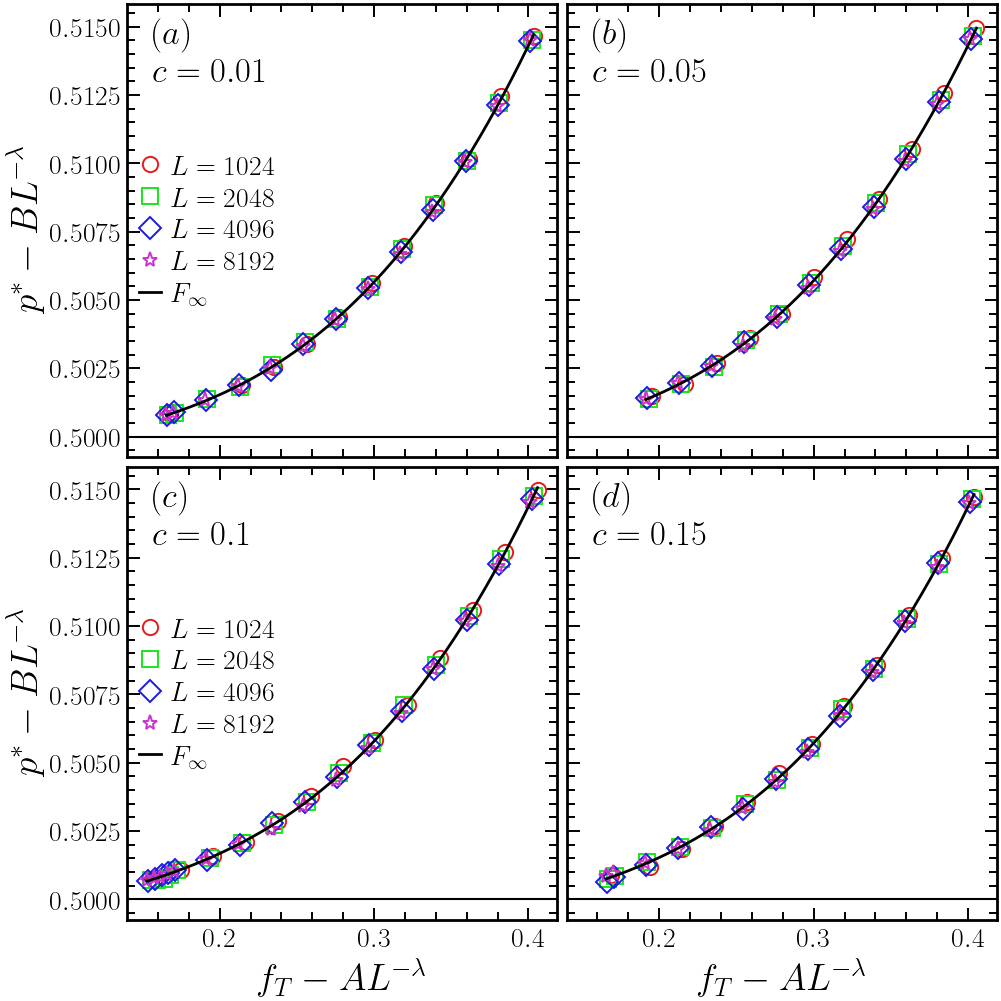

In [9]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(2 * base, 2 * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)

results_by_c = {}
pc = 0.5
for idx_c, ax in enumerate(axes.flatten()):
    c = c_lst[idx_c]

    result = collapse_for_c(
        df_series=df_series,
        c=c,
        L_lst=L_lst,
        nc=nc,
        p0=p0,
        P0=P0,
        order=order,
        dim=dim,
        type_perc='bond',
        min_samples_perc=5,
        p_cut=0.90,
        p_cut_mode='remove',
        domain_mode='common',
        degree=3,
        lambda_min=0.4,
        lambda_max=1.4,
        n_lambda=101,
        verbose=True,
    )

    results_by_c[c] = result

    for idx, L in enumerate(L_lst):
        df_col = result["collapse_data"][L]

        ax.plot(
            df_col["x_col"],
            df_col["y_col"],
            markers[idx],
            ms=11,
            mew=1.4,
            label=f'$L={L}$'
        )

    fit_curve = result["fit_curve"]

    ax.plot(
        fit_curve["x"],
        fit_curve["y"],
        'k-',
        lw=2.0,
        label=r'$F_\infty$'
    )

    ax.text(
        0.06,
        0.83,
        f'{labels[idx_c]} \n $c = {c}$',
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )
    ax.axhline(y=pc,color='k')
for ax in axes[:, 0]:
    ax.legend(loc='best')
    ax.set_ylabel(
        r"$p^* - B L^{-\lambda}$",
        fontsize=fs_label,
    )

for ax in axes[1, :]:
    ax.set_xlabel(
        r"$f_T - A L^{-\lambda}$",
        fontsize=fs_label,
    )

plt.savefig(results_folder + "/collapse_p_mean_2D_ns_1.pdf",dpi=300)
plt.show()

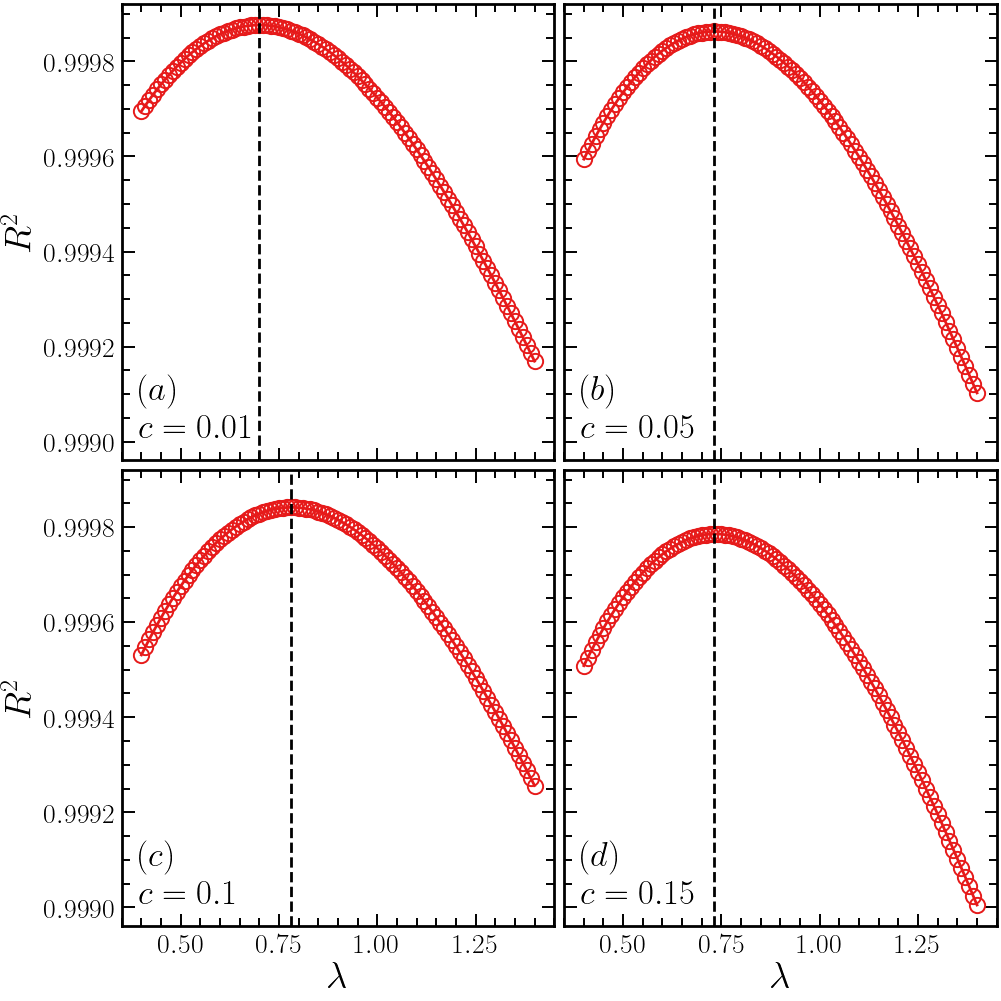

In [57]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(2 * base, 2 * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)

for idx_c, ax in enumerate(axes.flatten()):
    c = c_lst[idx_c]

    result = results_by_c[c]
    scan = result["scan"]

    ax.plot(
        scan["lambda"],
        scan["R2"],
        'o-',
        ms=11,
        mew=1.4,
        lw=2.0,
    )

    ax.axvline(
        result["lambda_best"],
        color='k',
        ls='--',
        lw=2.0,
    )

    ax.text(
        0.04,
        0.05,
        f'{labels[idx_c]} \n $c = {c}$',
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )

for ax in axes[:, 0]:
    ax.set_ylabel(r"$R^2$", fontsize=fs_label)

for ax in axes[1, :]:
    ax.set_xlabel(r"$\lambda$", fontsize=fs_label)

plt.savefig(results_folder + "/R2_lambda_2D_ns_1.pdf")
plt.show()

## Configuration Space

In [5]:
ft_common = pd.read_csv('../SOP_data/ft_values_2D.dat')
ft_common

,c,ft_min,ft_max,ns,dim,p0
0,0.01,0.164692,0.400000,1,2,0.8
1,0.05,0.190000,0.400000,1,2,0.8
2,0.10,0.151769,0.400000,1,2,0.8
3,0.15,0.164692,0.400000,1,2,0.8
4,0.20,0.160385,0.400000,1,2,0.8
5,0.01,0.156077,0.400000,2,2,0.8
6,0.05,0.138846,0.400000,2,2,0.8
7,0.10,0.143154,0.400000,2,2,0.8
8,0.15,0.134539,0.400000,2,2,0.8
9,0.20,0.143154,0.400000,2,2,0.8


### $c$ effects

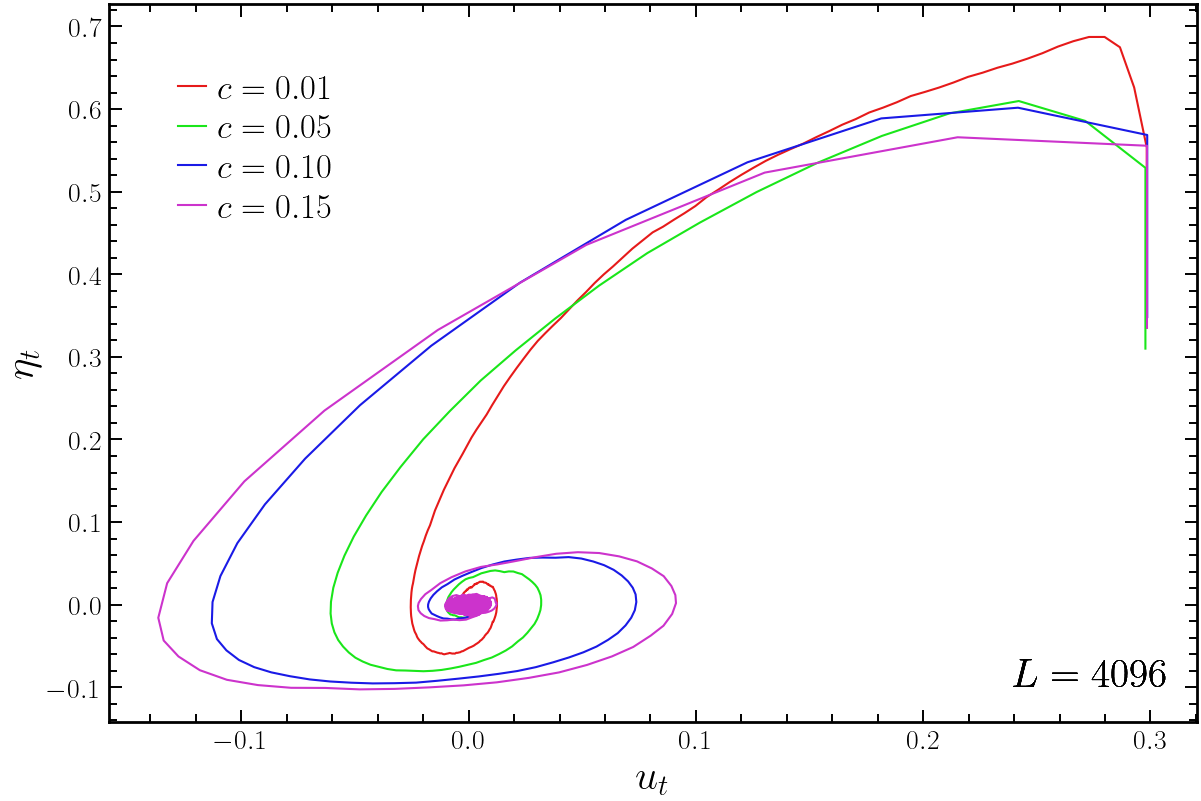

In [8]:
L = int(8192/2)
#c = 0.01
c_lst = [0.01, 0.05, 0.1, 0.15]
sw = 300
type_perc = 'bond'
dim = 2
ns = 1
rho = 1/ns
p0_target = 0.8
P0_target = 0.5
figsize =  (12, 8)
fig, ax = plt.subplots(
    figsize=figsize,
    constrained_layout=True,
    sharex=True
)
order_mean = 0
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$']
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 30
labels_size = 35
fs_labels_fig = 25
fs_l_fig = 35
fs_labels = 30
fs_legend = 25
fs_labels_fig = 30
colors = (0.9,0.1,0.1),(0.1,0.9,0.1),(0.1,0.1,0.9),(0.8,0.2,0.8)
for idx, c in enumerate(c_lst):
    fT = ft_common[ft_common['c']==c]['ft_min'].values[0]
    path = (
        f"../SOP_data/published_dynamic/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
    )

    fn = "properties_dynamic_bundle.json"
    df_bundle = read_dynamic_bundle(path + fn)
    
    row = df_bundle[(df_bundle["P0"] == P0_target) & (df_bundle["p0"] == p0_target) & (df_bundle["order"] == 0)].iloc[0]

    time = row["time"]
    pt_mean = row["pt_mean"]
    ft_mean = row["ft_mean"]
    t_eq = row["t_eq_mean"]
    p_star = row["p_star"]

    t = np.array(time)
    u_t = np.array(pt_mean) - p_star
    eta_t = np.array(ft_mean) - fT
    ax.plot(u_t, eta_t,ls='solid', color=colors[idx],label=f'$c = {c:.2f}$')
    
    
    ax.set_ylabel(r'$\eta_t$', fontsize=fs_labels)
    ax.set_xlabel('$u_t$', fontsize=fs_labels)
    ax.text(0.83, 0.05, f"$L = {L}$", transform=ax.transAxes , fontsize=fs_labels_fig)
ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=fs_legend,
    handlelength=0.8,
    borderaxespad=1.8
)
#plt.savefig(configurations_folder + f'/L_{L}_multiply_c.pdf')
plt.show()

### size effects - $L$

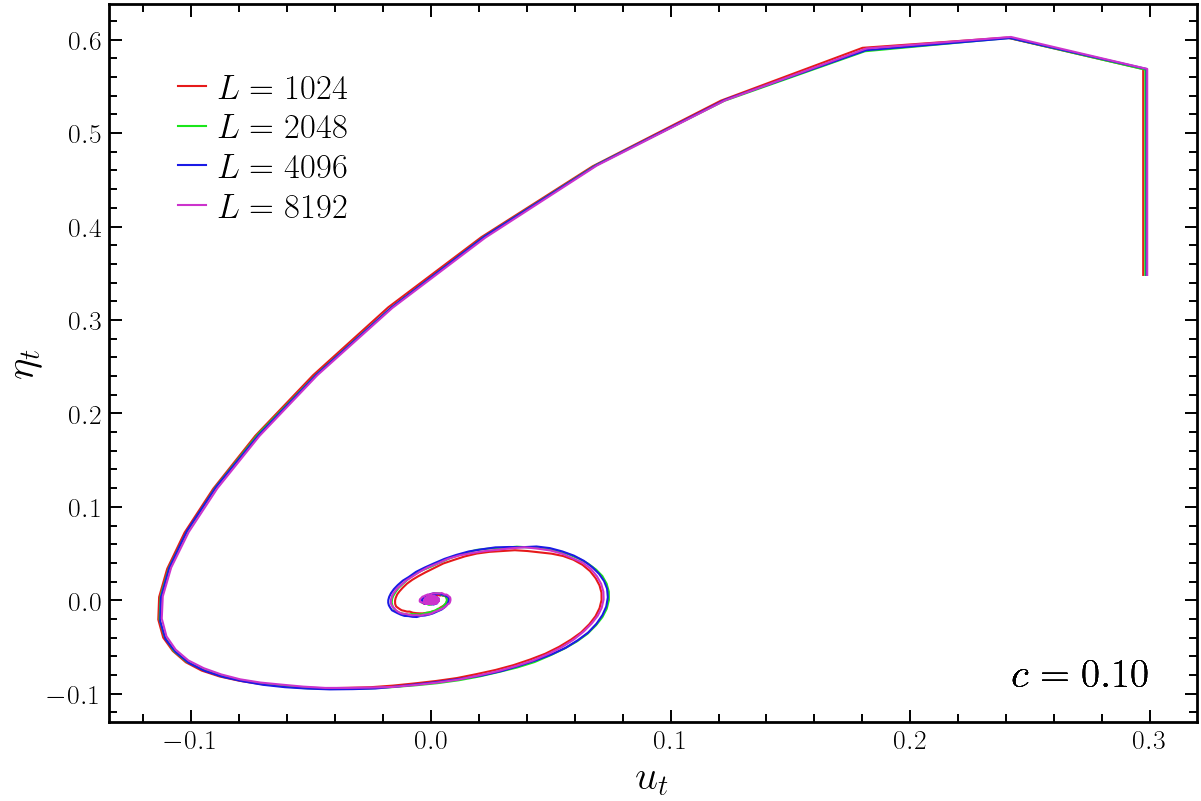

In [9]:
L_lst = [1024, 2048, 4096, 8192]
#c = 0.01
c = 0.1
sw = 300
type_perc = 'bond'
dim = 2
ns = 1
rho = 1/ns
p0_target = 0.8
P0_target = 0.5
figsize =  (12, 8)
fig, ax = plt.subplots(
    figsize=figsize,
    constrained_layout=True,
    sharex=True
)
order_mean = 0
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$']
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 30
labels_size = 35
fs_labels_fig = 25
fs_l_fig = 35
fs_labels = 30
fs_legend = 25
fs_labels_fig = 30
colors = (0.9,0.1,0.1),(0.1,0.9,0.1),(0.1,0.1,0.9),(0.8,0.2,0.8)

for idx, L in enumerate(L_lst):
    fT = ft_common[ft_common['c']==c]['ft_min'].values[0]
    path = (
        f"../SOP_data/published_dynamic/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
    )

    fn = "properties_dynamic_bundle.json"
    df_bundle = read_dynamic_bundle(path + fn)
    
    row = df_bundle[(df_bundle["P0"] == P0_target) & (df_bundle["p0"] == p0_target) & (df_bundle["order"] == 0)].iloc[0]

    time = row["time"]
    pt_mean = row["pt_mean"]
    ft_mean = row["ft_mean"]
    t_eq = row["t_eq_mean"]
    p_star = row["p_star"]

    t = np.array(time)
    u_t = np.array(pt_mean) - p_star
    eta_t = np.array(ft_mean) - fT
    ax.plot(u_t, eta_t, ls='solid', color=colors[idx],label=f'$L = {L}$')
    
    
    ax.set_ylabel(r'$\eta_t$', fontsize=fs_labels)
    ax.set_xlabel('$u_t$', fontsize=fs_labels)
    ax.text(0.83, 0.05, f"$c = {c:.2f}$", transform=ax.transAxes , fontsize=fs_labels_fig)
ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=fs_legend,
    handlelength=0.8,
    borderaxespad=1.8
)
plt.savefig(configurations_folder + f'/c_{c}_multiply_L.pdf')
plt.show()

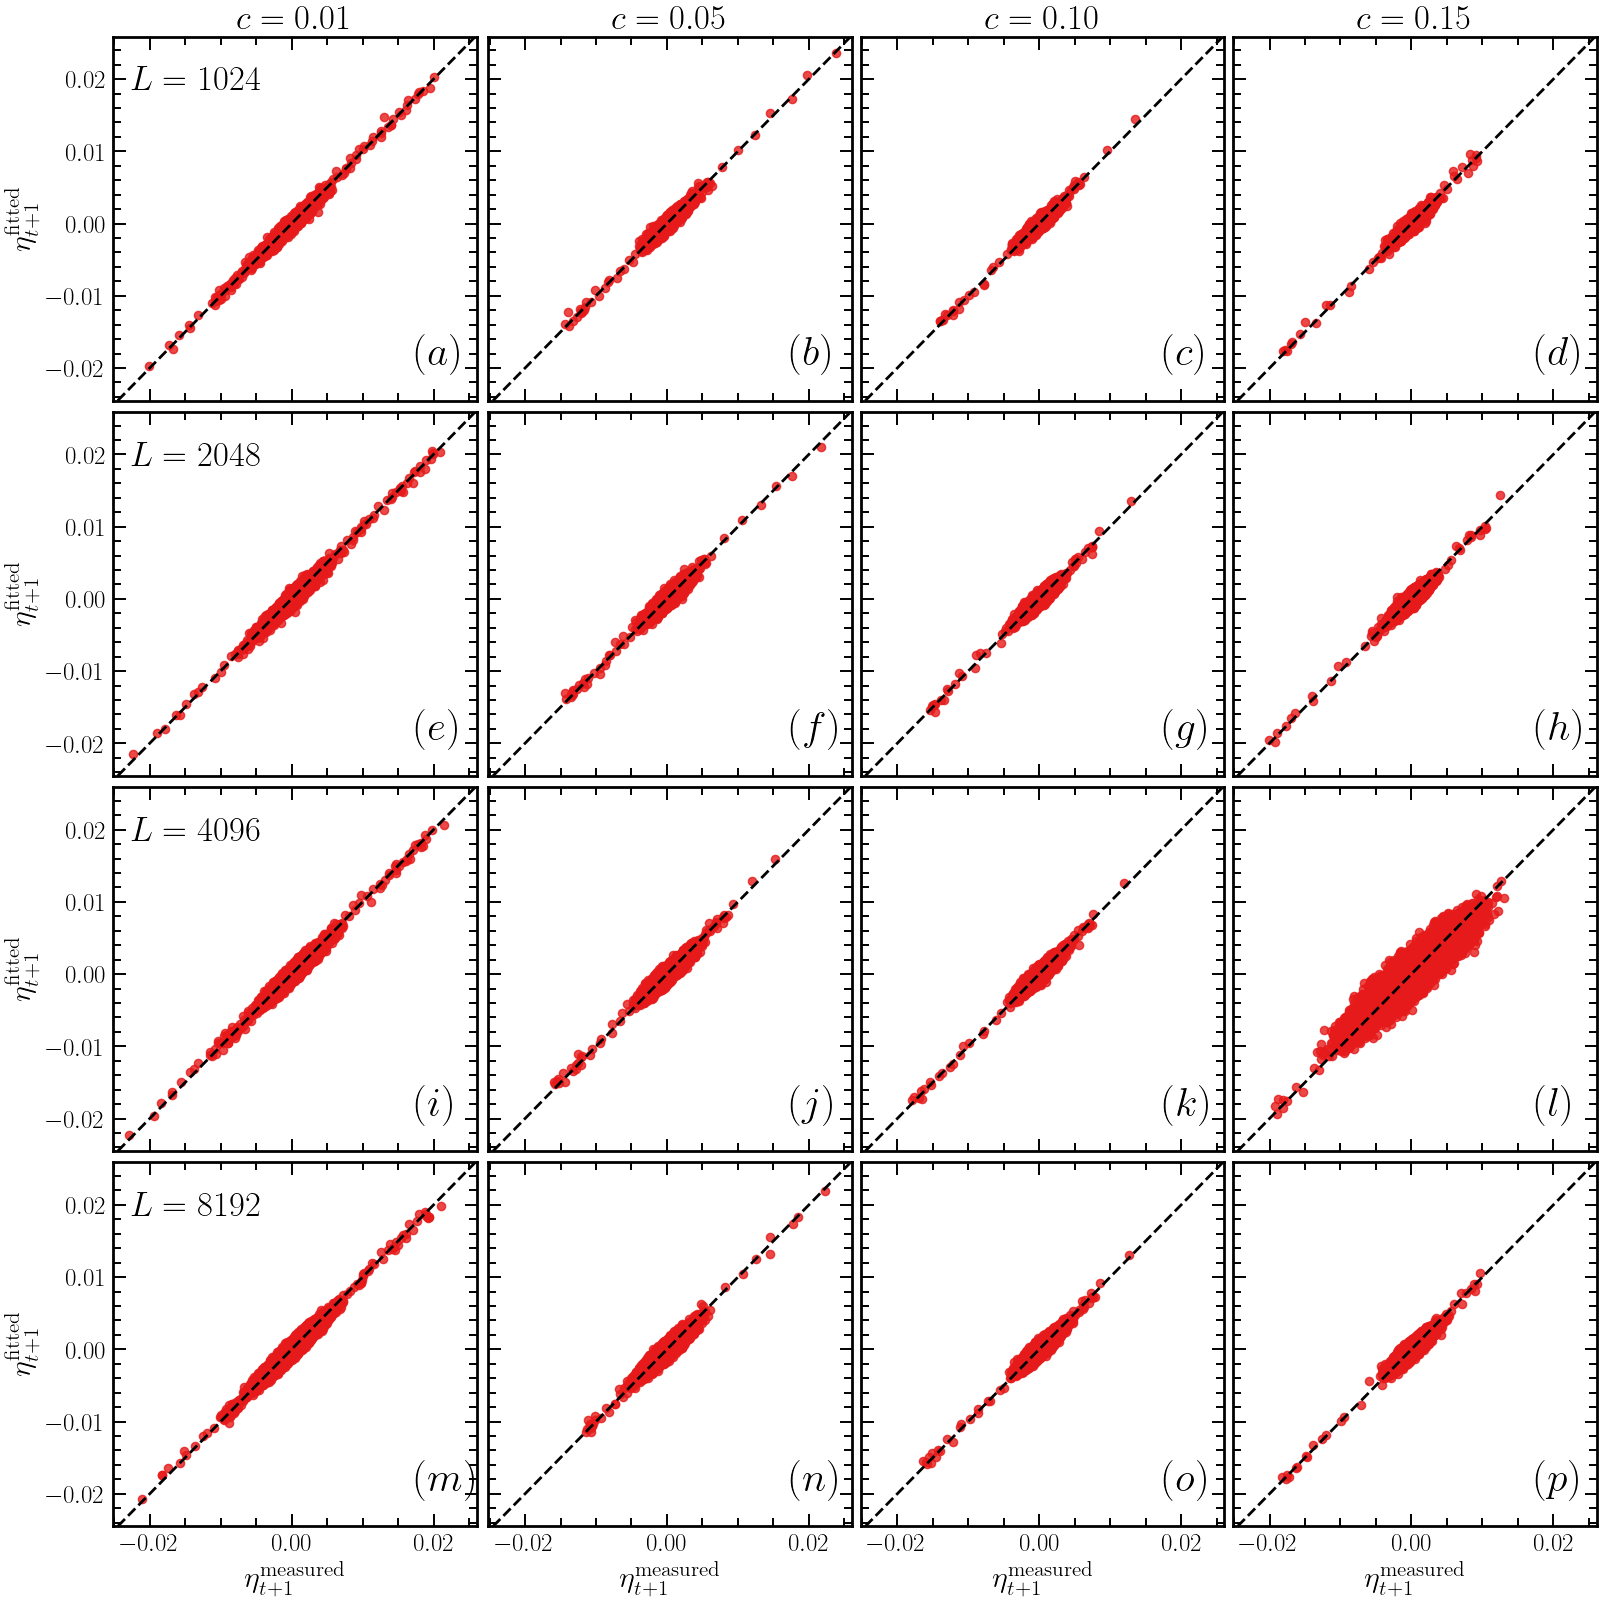

In [ ]:
L_lst = [1024, 2048, 4096, 8192]
sw = 300
P0_target = 0.5
p0_target = 0.8
type_perc = 'bond'
dim = 2
ns = 1
rho = 1 / ns
fs_l_fig = 30
c_lst = [0.01, 0.05, 0.10, 0.15]

base = 4

fig, axes = plt.subplots(
    len(L_lst),
    len(c_lst),
    figsize=(len(c_lst) * base, len(L_lst) * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)

# Caso len(L_lst)=1 ou len(c_lst)=1, garante formato 2D
axes = np.asarray(axes)
if axes.ndim == 0:
    axes = axes.reshape(1, 1)
elif axes.ndim == 1:
    axes = axes.reshape(len(L_lst), len(c_lst))


# Guarda todos os valores para definir limites globais iguais em x e y
all_vals = []


for idx_L, L in enumerate(L_lst):
    for idx_c, c in enumerate(c_lst):

        ax = axes[idx_L, idx_c]

        fT = ft_common[ft_common['c'] == c]['ft_min'].values[0]

        path = (
            f"../SOP_data/published_dynamic/{type_perc}_percolation/"
            f"num_colors_{ns}/dim_{dim}/L_{L}/"
            f"fT_constant/fT_{fT:.6e}/"
            f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
        )

        fn = "properties_dynamic_bundle.json"
        df_bundle = read_dynamic_bundle(path + fn)

        row = df_bundle[
            (df_bundle["P0"] == P0_target)
            & (df_bundle["p0"] == p0_target)
            & (df_bundle["order"] == 0)
        ].iloc[0]

        t = row["time"]
        p = row["pt_mean"]
        f = row["ft_mean"]
        t_stat = row["t_eq_mean"]

        res = fit_linear_feedback_model(
            t=t,
            p=p,
            f=f,
            c=c,
            fT=fT,
            t_stat=t_stat,
            u_max=0.03,
            eta_max=0.02,
            fit_after_t_stat=False,
        )

        x = np.asarray(res["eta_next_fit"])
        y = np.asarray(res["eta_next_pred"])

        # Salva valores para limite global
        all_vals.extend(x)
        all_vals.extend(y)

        ax.scatter(
            x,
            y,
            s=35,
            alpha=0.8,
            zorder=2,
        )

        ax.set_box_aspect(1)

        # Título da coluna
        if idx_L == 0:
            ax.set_title(fr"$c={c:.2f}$", fontsize=25)


# ==========================================================
# Limites globais iguais em x e y
# Isso força a reta y=x a cortar exatamente a diagonal
# ==========================================================

all_vals = np.asarray(all_vals, dtype=float)
all_vals = all_vals[np.isfinite(all_vals)]

lim_min = np.min(all_vals)
lim_max = np.max(all_vals)

pad = 0.05 * (lim_max - lim_min)
if pad == 0:
    pad = 1e-6

lim_min -= pad
lim_max += pad

for ax in axes.flatten():

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        ls="--",
        color="black",
        lw=2.0,
        zorder=1,
    )


# Labels do eixo y e texto com L
for idx, ax in enumerate(axes[:, 0]):

    ax.set_ylabel(
        r"$\eta_{t+1}^{\mathrm{fitted}}$",
        fontsize=22,
    )

    ax.text(
        0.05,
        0.92,
        fr"$L={L_lst[idx]}$",
        transform=ax.transAxes,
        fontsize=25,
        va="top",
        ha="left",
    )


# Labels do eixo x
for ax in axes[-1, :]:

    ax.set_xlabel(
        r"$\eta_{t+1}^{\mathrm{measured}}$",
        fontsize=22,
    )


# Ajustes dos ticks e labels (a), (b), (c), ...
for idx, ax in enumerate(axes.flatten()):

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=18,
    )

    ax.minorticks_on()

    ax.text(
        0.83,
        0.10,
        label(idx),
        transform=ax.transAxes,
        fontsize=fs_l_fig,
    )


plt.savefig(
    results_folder + "/eta_next_fit_vs_pred_subplots_2D_ns_1.pdf",
    bbox_inches="tight",
)

plt.show()

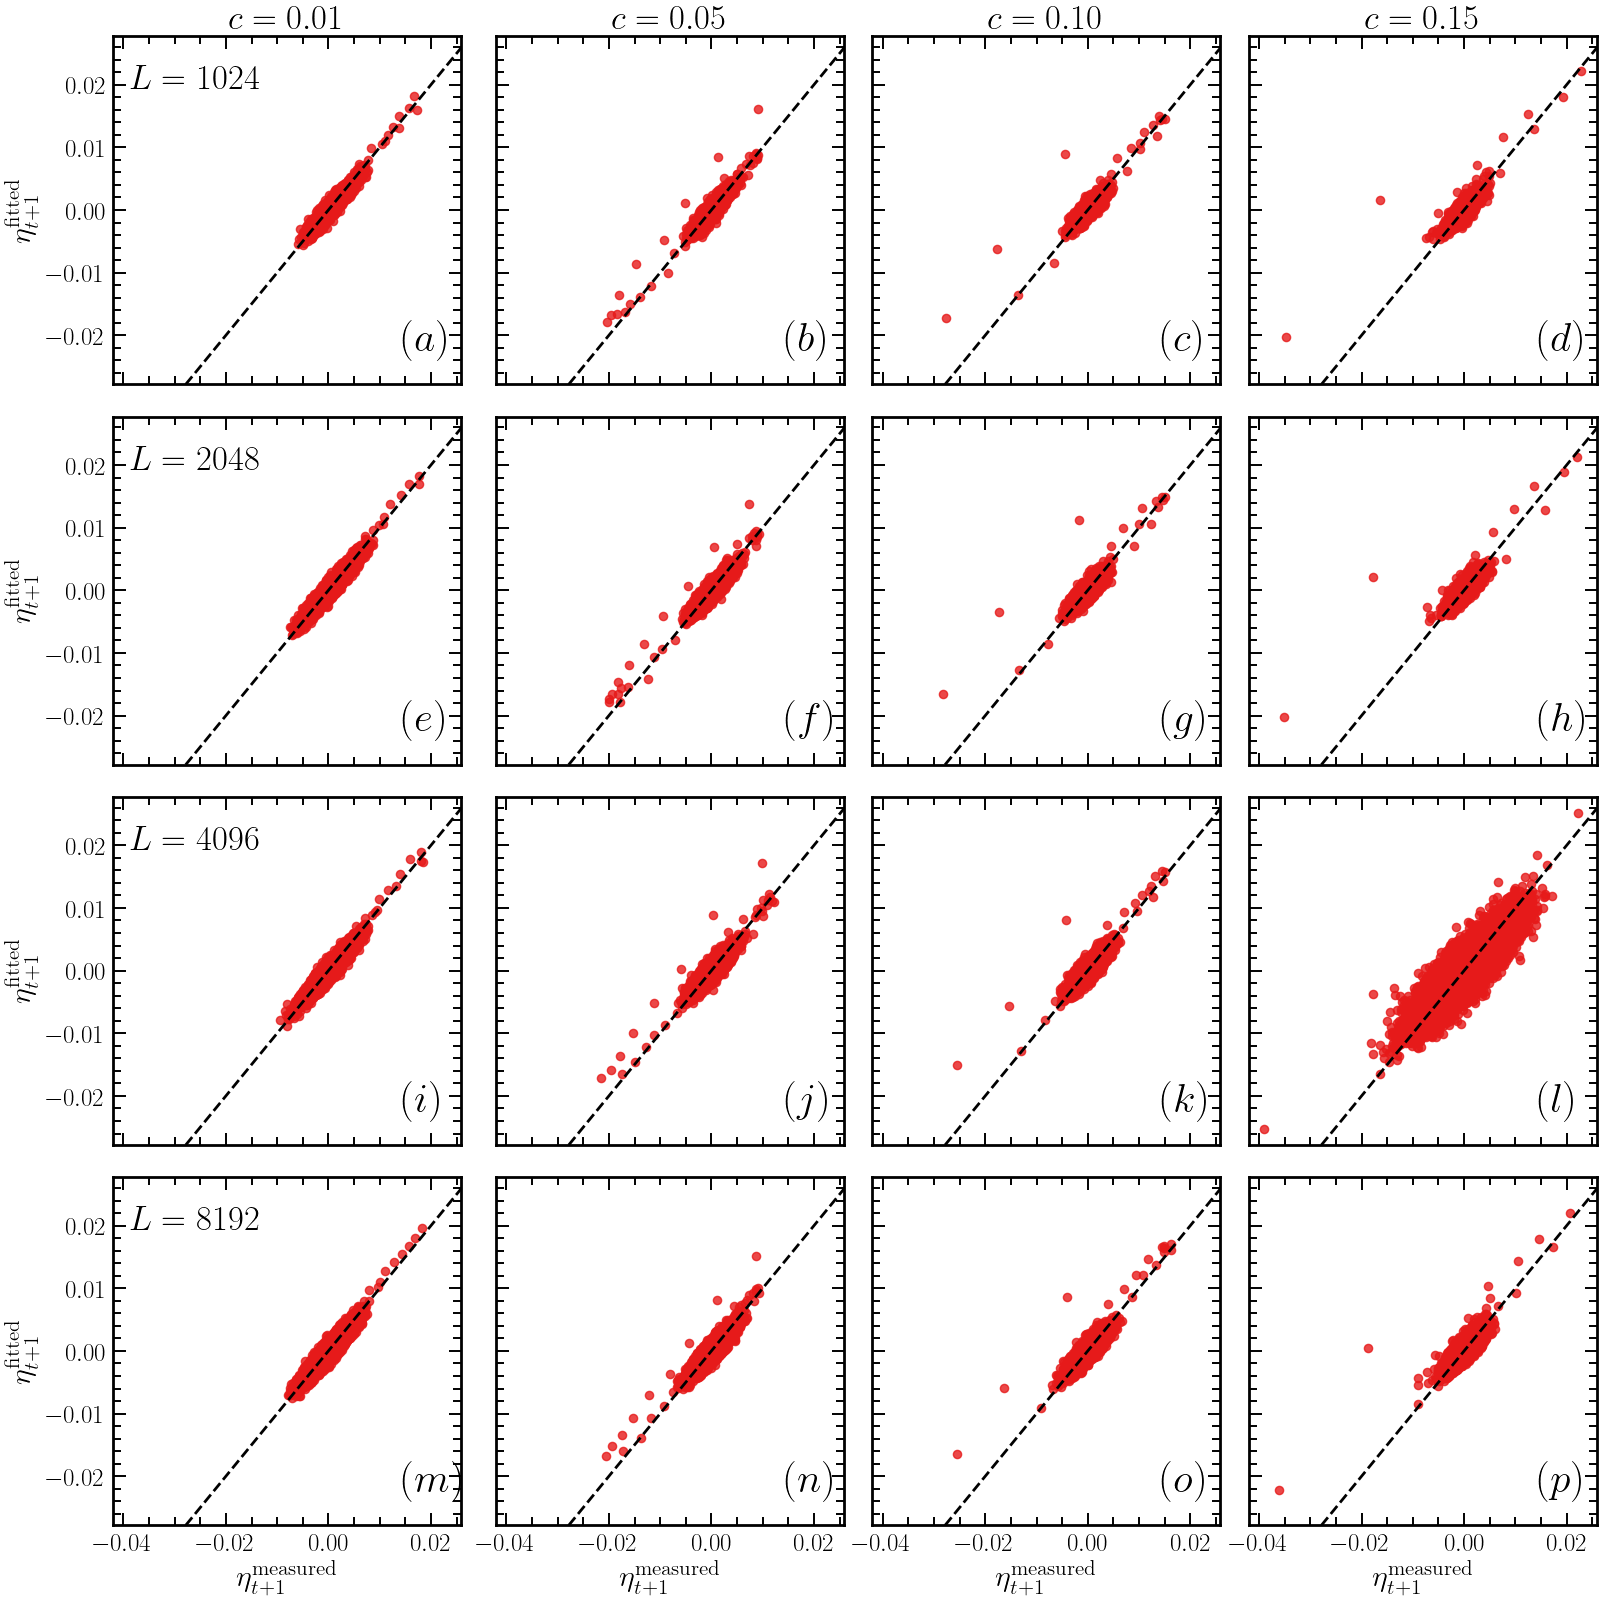

In [14]:
L_lst = [1024, 2048, 4096, 8192]
sw = 300
P0_target = 0.5
p0_target = 0.8
type_perc = 'bond'
dim = 2
ns = 1
rho = 1 / ns
fs_l_fig = 30
c_lst = [0.01, 0.05, 0.10, 0.15]

base = 4

fig, axes = plt.subplots(
    len(L_lst),
    len(c_lst),
    figsize=(len(c_lst) * base, len(L_lst) * base),
    constrained_layout=True,
    sharey=True,
    sharex=True,
)

# Caso len(L_lst)=1 ou len(c_lst)=1, garante formato 2D
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(len(L_lst), len(c_lst))

for idx_L, L in enumerate(L_lst):
    for idx_c, c in enumerate(c_lst):

        ax = axes[idx_L, idx_c]

        fT = ft_common[ft_common['c'] == c]['ft_max'].values[0]

        path = (
            f"../SOP_data/published_dynamic/{type_perc}_percolation/"
            f"num_colors_{ns}/dim_{dim}/L_{L}/"
            f"fT_constant/fT_{fT:.6e}/"
            f"c_{c:.6e}/rho_{rho:.4e}/stationary_window_{sw}/"
        )

        fn = "properties_dynamic_bundle.json"
        df_bundle = read_dynamic_bundle(path + fn)

        row = df_bundle[
            (df_bundle["P0"] == P0_target)
            & (df_bundle["p0"] == p0_target)
            & (df_bundle["order"] == 0)
        ].iloc[0]

        t = row["time"]
        p = row["pt_mean"]
        f = row["ft_mean"]
        t_stat = row["t_eq_mean"]

        res = fit_linear_feedback_model(
            t=t,
            p=p,
            f=f,
            c=c,
            fT=fT,
            t_stat=t_stat,
            u_max=0.03,
            eta_max=0.02,
            fit_after_t_stat=False
        )

        x = np.asarray(res["eta_next_fit"])
        y = np.asarray(res["eta_next_pred"])

        ax.scatter(
            x,
            y,
            s=35,
            alpha=0.8
        )

        min_val = min(np.min(x), np.min(y))
        max_val = max(np.max(x), np.max(y))

        ax.axline(
            (0, 0),
            slope=1,
            ls="--",
            color="black",
            lw=2.0,
            zorder=1
        )

        ax.set_box_aspect(1)

        # Título da coluna
        if idx_L == 0:
            ax.set_title(fr"$c={c:.2f}$", fontsize=25)

for idx, ax in enumerate(axes[:, 0]):
    ax.set_ylabel(r"$\eta_{t+1}^{\mathrm{fitted}}$", fontsize=22)
    ax.text(
            0.05,
            0.92,
            fr"$L={L_lst[idx]}$",
            transform=ax.transAxes,
            fontsize=25,
            va="top",
            ha="left"
            )
for ax in axes[-1, :]:
    ax.set_xlabel(r"$\eta_{t+1}^{\mathrm{measured}}$", fontsize=22)

for idx, ax in enumerate(axes.flatten()):
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.minorticks_on()
    ax.text(
        0.83,
        0.10,
        label(idx),
        transform=ax.transAxes,
        fontsize=fs_l_fig
    )
#plt.savefig(results_folder + "/eta_next_fit_vs_pred_subplots_2D_ns_1.pdf")
plt.show()

In [13]:
if res["spectral_radius"] < 1:
    print("O ponto fixo é linearmente estável.")
else:
    print("O ponto fixo é linearmente instável ou marginal.")

if np.iscomplex(res["lambda_1"]) or np.iscomplex(res["lambda_2"]):
    print("A convergência é oscilatória amortecida se |lambda| < 1.")
else:
    print("A convergência é monotônica ou alternada, dependendo do sinal dos autovalores.")

O ponto fixo é linearmente estável.
A convergência é oscilatória amortecida se |lambda| < 1.
